# 01 - Data Understanding and Exploratory Data Analysis

## Objective
This notebook aims to characterize the ECG dataset from both a general and experiment-oriented perspective.

The analysis has two purposes:
1. to describe the dataset structure, demographic composition, and signal properties;
2. to support methodological decisions for the privacy-risk experiments, namely preprocessing, lead selection, segmentation, and similarity analysis.

Because this work is part of a thesis experiment, the EDA is designed not only to describe the data, but also to justify the experimental pipeline.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT / "src"))

DATA_PATH = PROJECT_ROOT / "data" / "raw"
wfdb_path = DATA_PATH / "WFDBRecords"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loading import load_record
from eda_utils import (
    build_metadata_table,
    build_demographic_table,
    plot_random_ecg,
    compute_intra_inter_similarity,
    plot_similarity_distributions
)

## Dataset overview

The dataset used in this experiment is the PhysioNet database *A large-scale 12-lead electrocardiogram database for arrhythmia study*.

According to the dataset description, it contains tens of thousands of 12-lead ECG recordings, each with fixed duration and standard sampling frequency, making it suitable for large-scale signal analysis and downstream machine learning experiments. In the reference dissertation, the same database is described as containing ECG recordings stored in `.mat` and `.hea` files, with 1 record corresponding to 1 patient, signal duration of 10 seconds, and metadata such as age, sex, diagnosis codes, sampling frequency, and number of samples. 

In this thesis experiment, the goal is not arrhythmia classification itself, but privacy-oriented analysis of ECG signals, including re-identification and linkability risk.

In [8]:
hea_files = list(wfdb_path.rglob("*.hea"))
mat_files = list(wfdb_path.rglob("*.mat"))

print("Total records:", len(hea_files))
print("MAT files:", len(mat_files))
print("Consistent:", len(hea_files) == len(mat_files))

Total records: 45152
MAT files: 45152
Consistent: True


## Dataset integrity

This step verifies whether the downloaded dataset is structurally complete. In WFDB-based ECG datasets, each recording is expected to have a matching header file (`.hea`) and signal file (`.mat` or equivalent). Ensuring this correspondence is important before any loading, preprocessing, or segmentation step.

In [9]:
record = hea_files[0].with_suffix("")
signal, fs, leads = load_record(record)

print("Record ID:", hea_files[0].stem)
print("Shape:", signal.shape)
print("Sampling rate:", fs)
print("Duration (s):", signal.shape[0] / fs)
print("Leads:", leads)
print("Min amplitude:", np.min(signal))
print("Max amplitude:", np.max(signal))

Record ID: JS00001
Shape: (5000, 12)
Sampling rate: 500
Duration (s): 10.0
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Min amplitude: -1.649
Max amplitude: 2.752


## Single-record inspection

A first inspection of one ECG recording is used to confirm the empirical characteristics of the dataset:
- number of samples,
- number of leads,
- sampling frequency,
- signal duration,
- amplitude range.

This step is important to validate that the signals match the documented structure before any general analysis is performed.

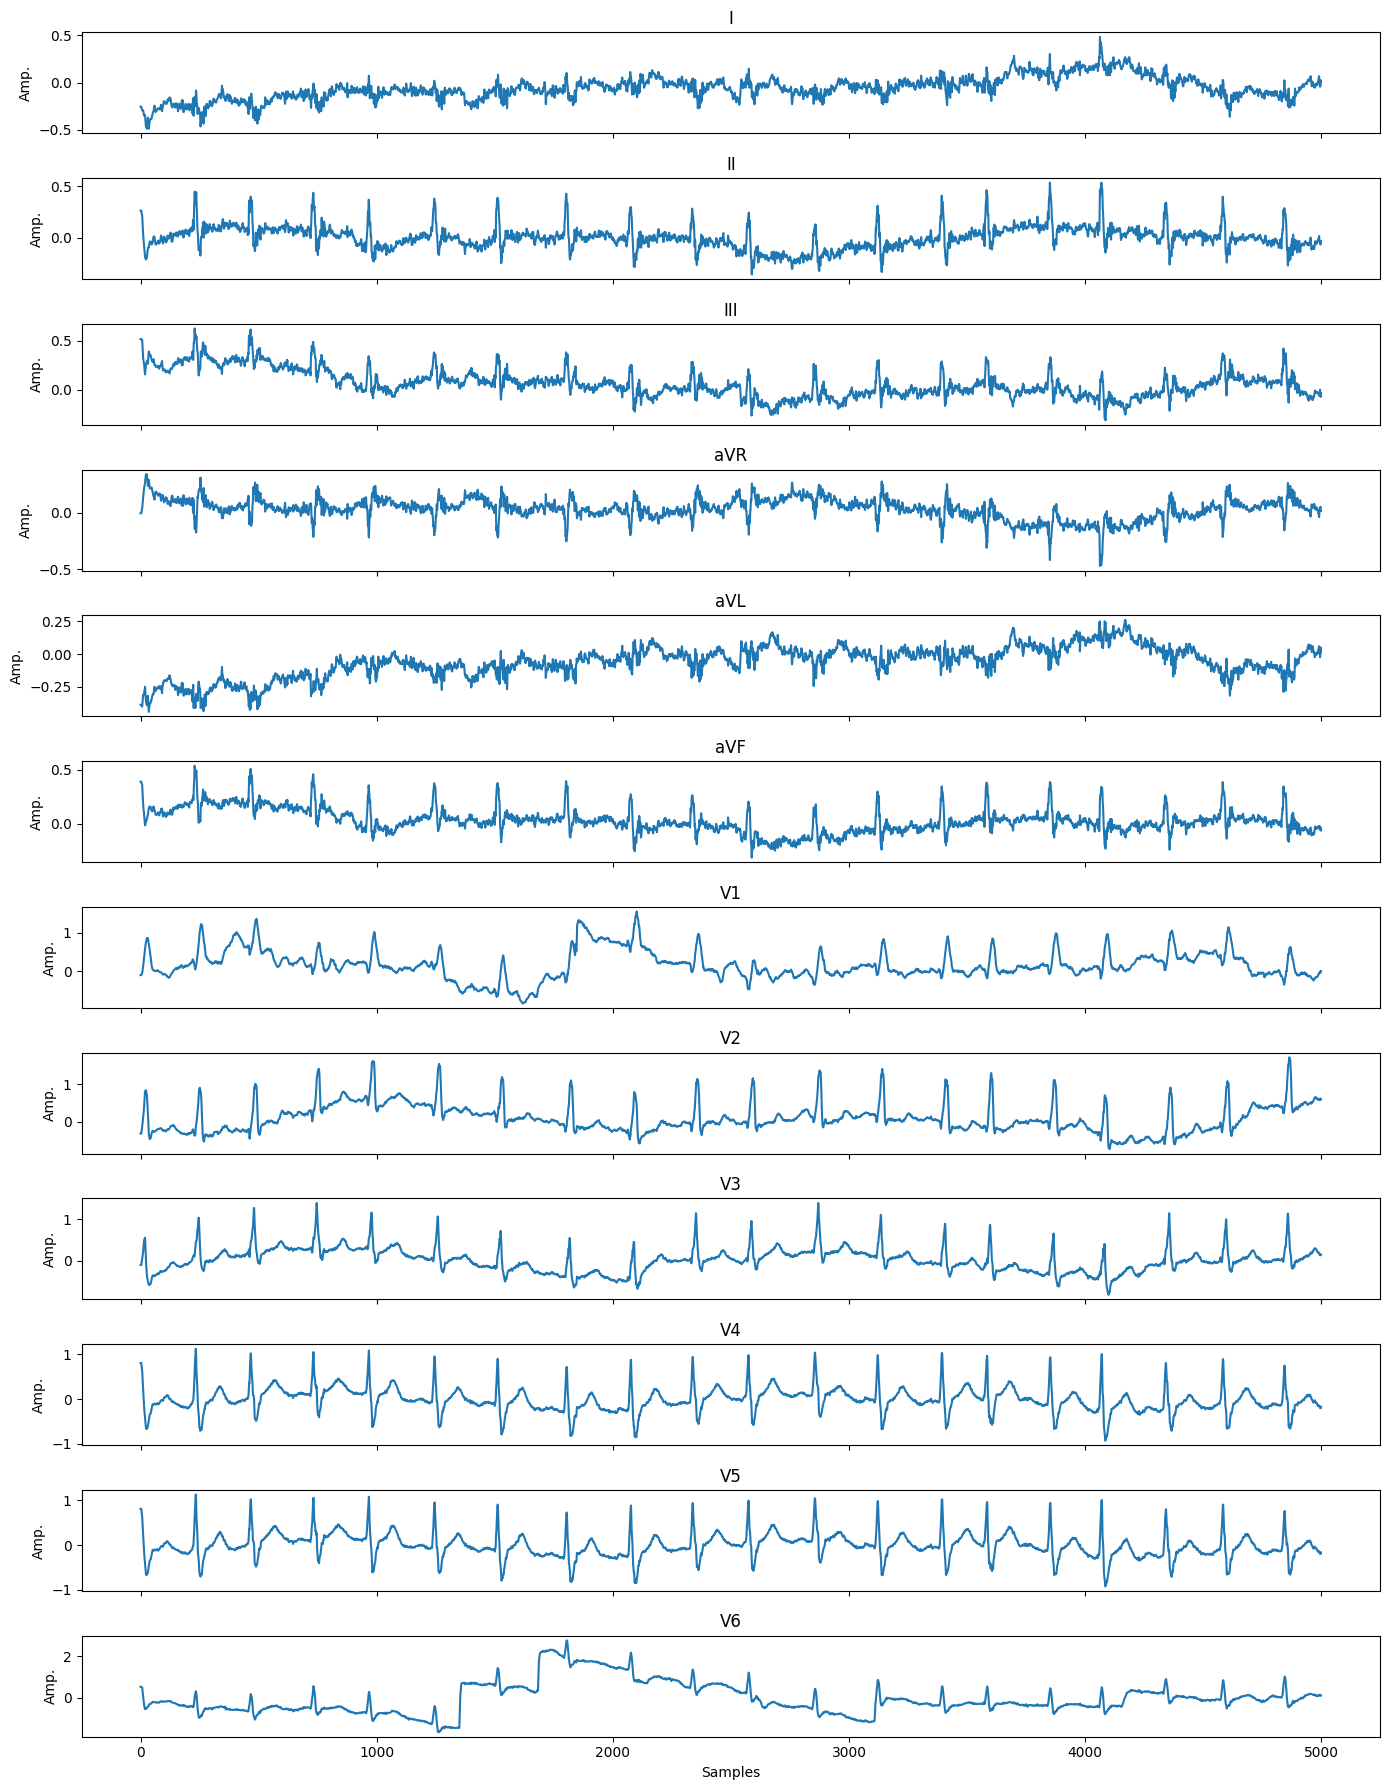

In [10]:
fig, axes = plt.subplots(12,1, figsize=(14,18), sharex=True)

for i in range(12):
    axes[i].plot(signal[:,i])
    axes[i].set_title(leads[i])
    axes[i].set_ylabel("Amp.")

plt.xlabel("Samples")
plt.tight_layout()
plt.show()

## Visual inspection of ECG morphology

Plotting all leads of one recording allows a first visual assessment of:
- signal morphology,
- lead-specific differences,
- possible artifacts or abnormal patterns.

This visual step is especially relevant in ECG analysis, where lead orientation and waveform morphology carry important information.

In [11]:
metadata_df = build_metadata_table(hea_files, load_record)

metadata_df.head()

,record_id,samples,leads,fs,duration_sec,mean,std,min,max
0,JS00001,5000,12,500,10.0,0.019512,0.317381,-1.649,2.752
1,JS00002,5000,12,500,10.0,0.004972,0.142176,-1.596,1.508
2,JS00004,5000,12,500,10.0,-0.008400,0.202038,-1.942,2.167
3,JS00005,5000,12,500,10.0,-0.004696,0.349086,-2.538,2.699
4,JS00006,5000,12,500,10.0,-0.002072,0.137267,-0.805,1.352


In [12]:
metadata_df.describe()

,samples,leads,fs,duration_sec,mean,std,min,max
count,45150.0,45150.0,45150.0,45150.0,45053.000000,45053.000000,45053.000000,45053.000000
mean,5000.0,12.0,500.0,10.0,0.001558,0.234309,-1.999203,2.381791
std,0.0,0.0,0.0,0.0,0.016144,0.124699,1.780817,1.743665
min,5000.0,12.0,500.0,10.0,-0.441685,0.025355,-32.598000,0.205000
25%,5000.0,12.0,500.0,10.0,-0.001048,0.166974,-2.220000,1.566000
50%,5000.0,12.0,500.0,10.0,0.002413,0.208713,-1.625000,2.040000
75%,5000.0,12.0,500.0,10.0,0.005217,0.265157,-1.210000,2.674000
max,5000.0,12.0,500.0,10.0,0.452079,3.371281,-0.171000,32.767000


## Metadata summary table

A metadata table is built to summarize structural and statistical properties of the ECG recordings. This allows:
- checking consistency across records,
- identifying corrupted or anomalous files,
- quantifying basic amplitude variation,
- supporting downstream EDA steps.

In [13]:
print(metadata_df["samples"].value_counts().sort_index())
print(metadata_df["leads"].value_counts().sort_index())
print(metadata_df["fs"].value_counts().sort_index())
print(metadata_df["duration_sec"].describe())

samples
5000    45150
Name: count, dtype: int64
leads
12    45150
Name: count, dtype: int64
fs
500    45150
Name: count, dtype: int64
count    45150.0
mean        10.0
std          0.0
min         10.0
25%         10.0
50%         10.0
75%         10.0
max         10.0
Name: duration_sec, dtype: float64


## Structural consistency

This analysis checks whether the ECG recordings are structurally homogeneous in terms of:
- number of samples,
- number of leads,
- sampling rate,
- duration.

Structural homogeneity is important because later stages such as segmentation, feature extraction, and similarity analysis assume comparable signal format across patients.

In [14]:
demo_df = build_demographic_table(hea_files)
demo_df.head()

,record_id,age,sex,dx
0,JS00001,85,Male,"164889003,59118001,164934002"
1,JS00002,59,Female,"426177001,164934002"
2,JS00004,66,Male,426177001
3,JS00005,73,Female,"164890007,429622005,428750005"
4,JS00006,46,Female,426177001


## Demographic and clinical metadata

A second metadata table is extracted from the WFDB header files. It contains demographic and clinical information such as age, sex, and diagnosis codes.

In [15]:
demo_df["sex"].value_counts(dropna=False)

sex
Male       25454
Female     19676
Unknown       22
Name: count, dtype: int64

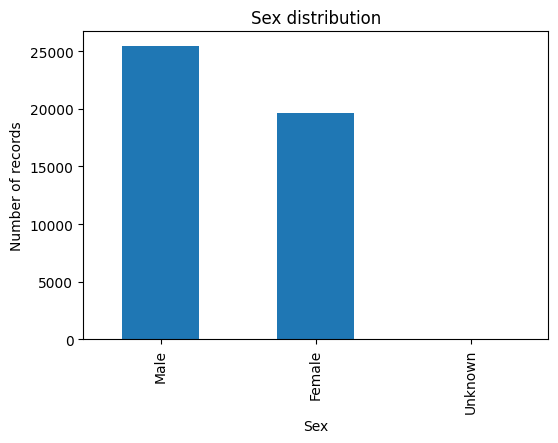

In [16]:
demo_df["sex"].value_counts(dropna=False).plot(kind="bar", figsize=(6,4))
plt.title("Sex distribution")
plt.ylabel("Number of records")
plt.xlabel("Sex")
plt.show()

In [29]:
AFL_CODE = "164889003"

demo_df["is_afl"] = demo_df["dx"].apply(
    lambda x: AFL_CODE in str(x) if pd.notna(x) else False
)

demo_df["label"] = demo_df["is_afl"].map({
    True: "AFL",
    False: "Non-AFL"
})

demo_df["label"].value_counts()

label
Non-AFL    43372
AFL         1780
Name: count, dtype: int64

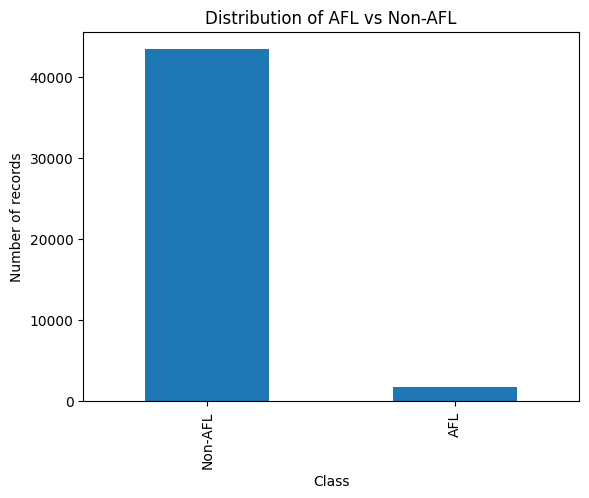

In [30]:
demo_df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of AFL vs Non-AFL")
plt.xlabel("Class")
plt.ylabel("Number of records")
plt.show()

In [31]:
pd.crosstab(demo_df["sex"], demo_df["label"])

label,AFL,Non-AFL
sex,,
Female,739,18937
Male,1041,24413
Unknown,0,22


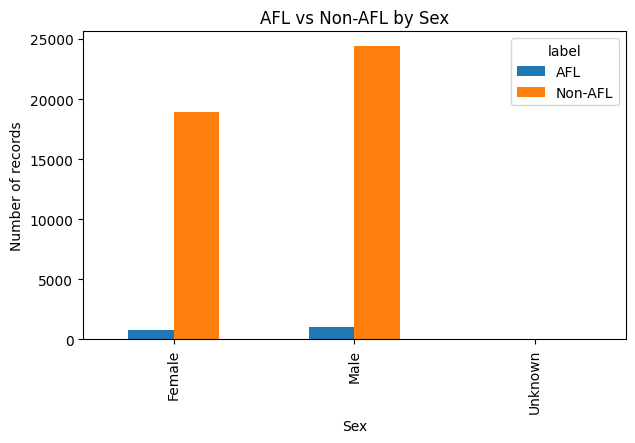

In [32]:
pd.crosstab(demo_df["sex"], demo_df["label"]).plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("AFL vs Non-AFL by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of records")
plt.show()

In [33]:
sex_class_pct = pd.crosstab(
    demo_df["sex"],
    demo_df["label"],
    normalize="index"
)

sex_class_pct

label,AFL,Non-AFL
sex,,
Female,0.037558,0.962442
Male,0.040897,0.959103
Unknown,0.000000,1.000000


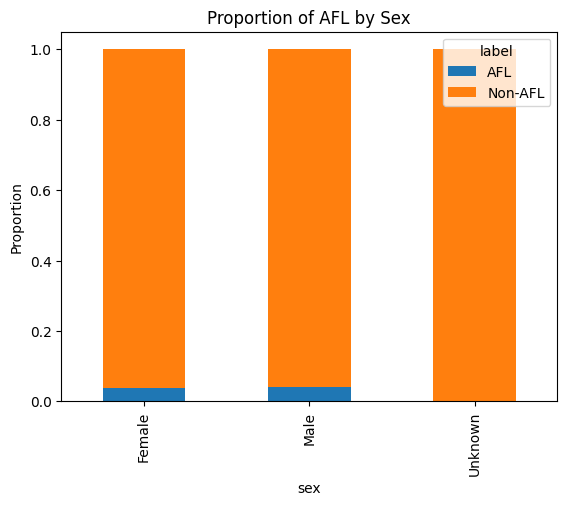

In [34]:
sex_class_pct.plot(kind="bar", stacked=True)

plt.title("Proportion of AFL by Sex")
plt.ylabel("Proportion")
plt.show()

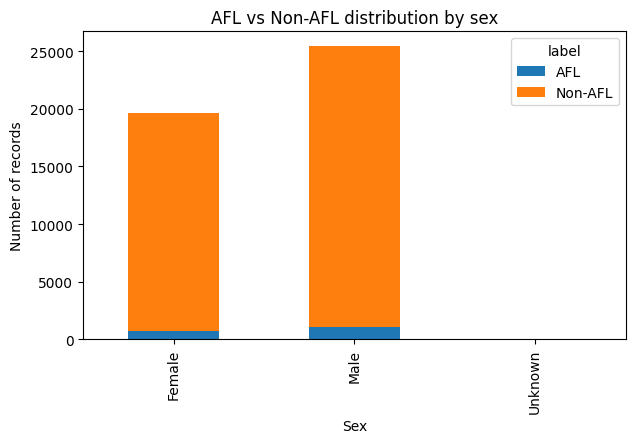

In [35]:
ct = pd.crosstab(demo_df["sex"], demo_df["label"])

ct.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.title("AFL vs Non-AFL distribution by sex")
plt.xlabel("Sex")
plt.ylabel("Number of records")
plt.show()

## Class distribution and demographic breakdown

The dataset was further analyzed to determine the distribution of atrial flutter (AFL) and non-AFL recordings. The results show a strong class imbalance, with AFL representing a small fraction of the total dataset.

This imbalance is expected in clinical datasets and has implications for downstream modeling and evaluation.

Additionally, the distribution of AFL and non-AFL cases was analyzed across sex categories to investigate potential demographic differences in the dataset population.

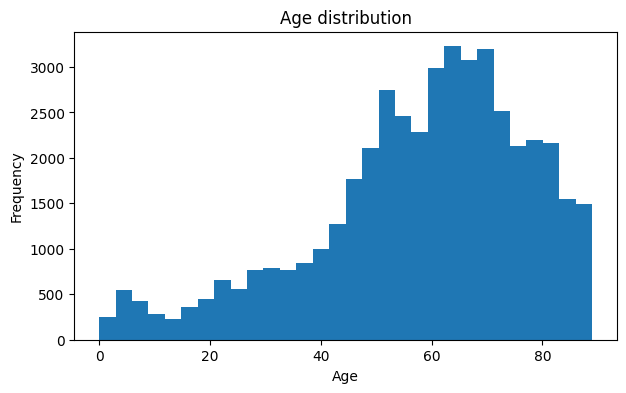

In [18]:
ages = pd.to_numeric(demo_df["age"], errors="coerce")

plt.figure(figsize=(7,4))
plt.hist(ages.dropna(), bins=30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Demographic analysis

Demographic analysis is relevant because ECG characteristics may vary with age and sex. This step helps characterize the population represented in the dataset and identify possible sources of physiological variability.

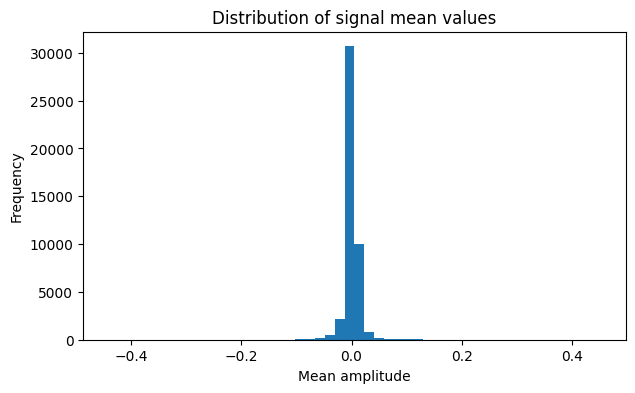

In [19]:
plt.figure(figsize=(7,4))
plt.hist(metadata_df["mean"], bins=50)
plt.title("Distribution of signal mean values")
plt.xlabel("Mean amplitude")
plt.ylabel("Frequency")
plt.show()

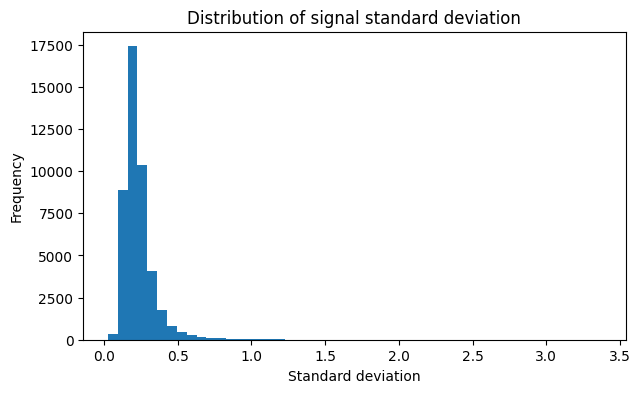

In [20]:
plt.figure(figsize=(7,4))
plt.hist(metadata_df["std"], bins=50)
plt.title("Distribution of signal standard deviation")
plt.xlabel("Standard deviation")
plt.ylabel("Frequency")
plt.show()

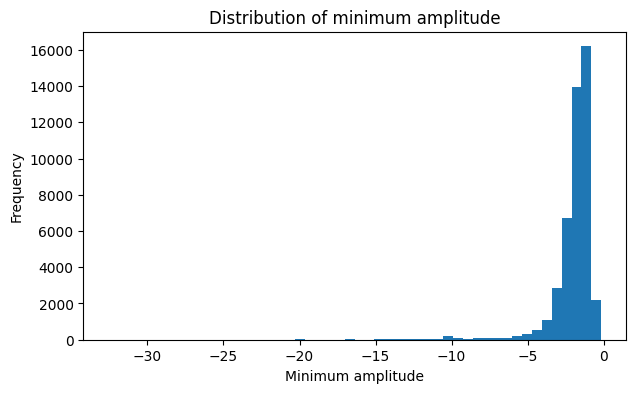

In [21]:
plt.figure(figsize=(7,4))
plt.hist(metadata_df["min"], bins=50)
plt.title("Distribution of minimum amplitude")
plt.xlabel("Minimum amplitude")
plt.ylabel("Frequency")
plt.show()

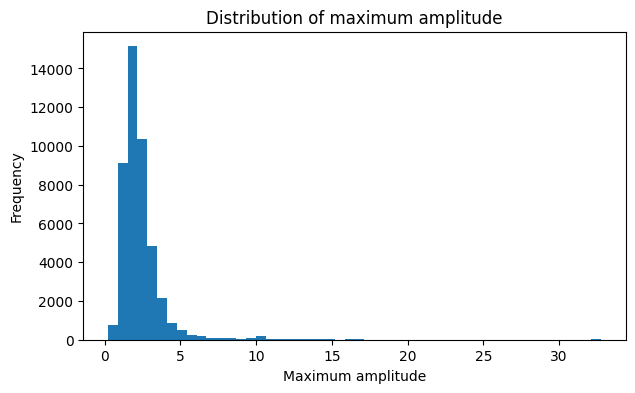

In [22]:
plt.figure(figsize=(7,4))
plt.hist(metadata_df["max"], bins=50)
plt.title("Distribution of maximum amplitude")
plt.xlabel("Maximum amplitude")
plt.ylabel("Frequency")
plt.show()

## Statistical signal analysis

These distributions provide a general view of ECG amplitude behavior across records and help identify possible outliers or scaling issues.

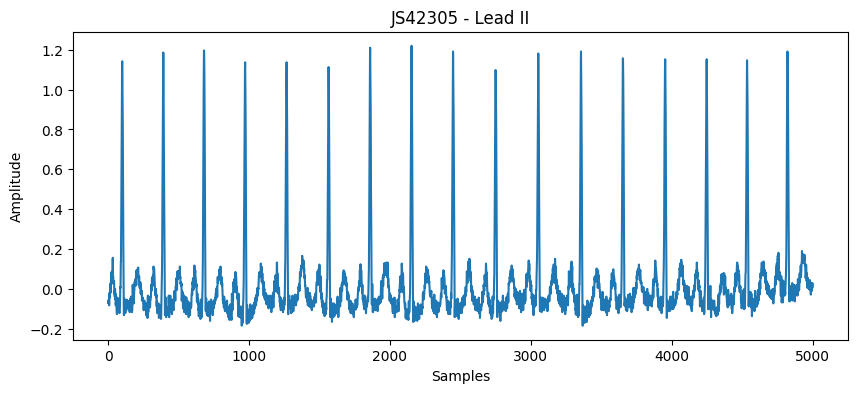

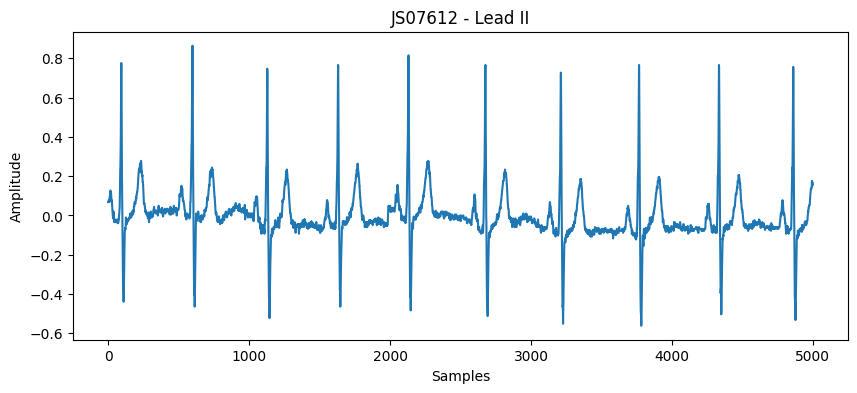

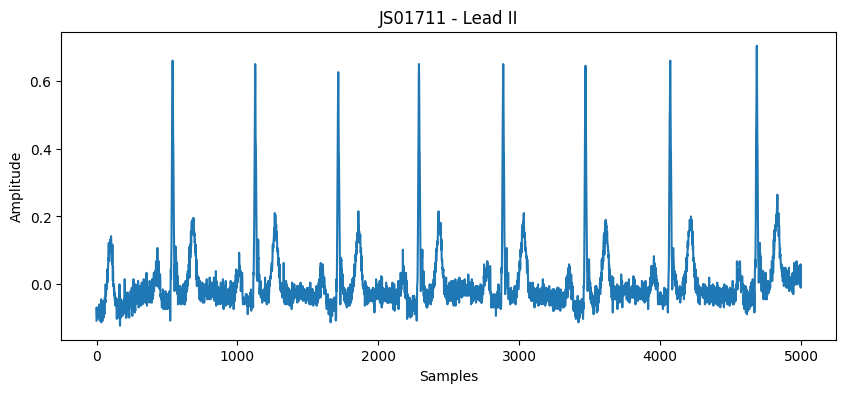

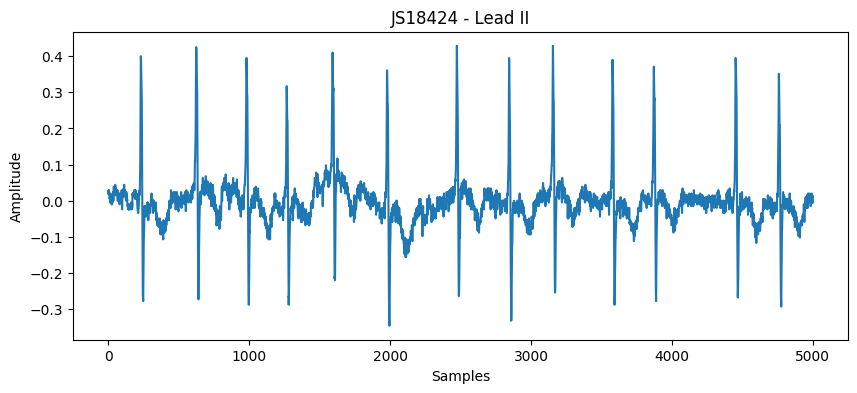

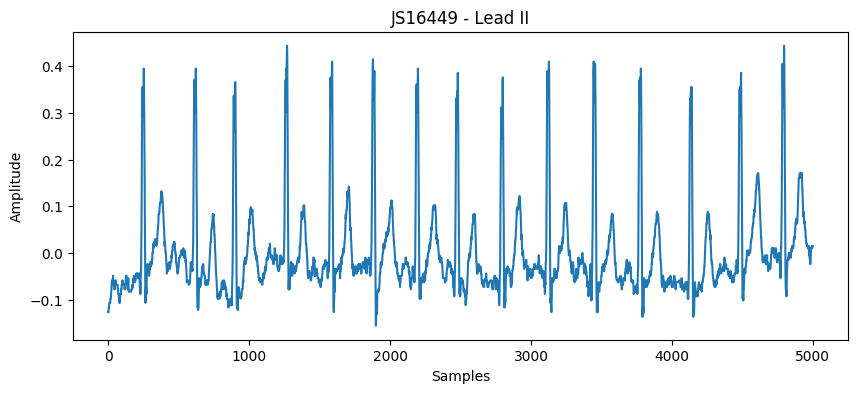

In [23]:
plot_random_ecg(hea_files, load_record, n=5, lead_idx=1)

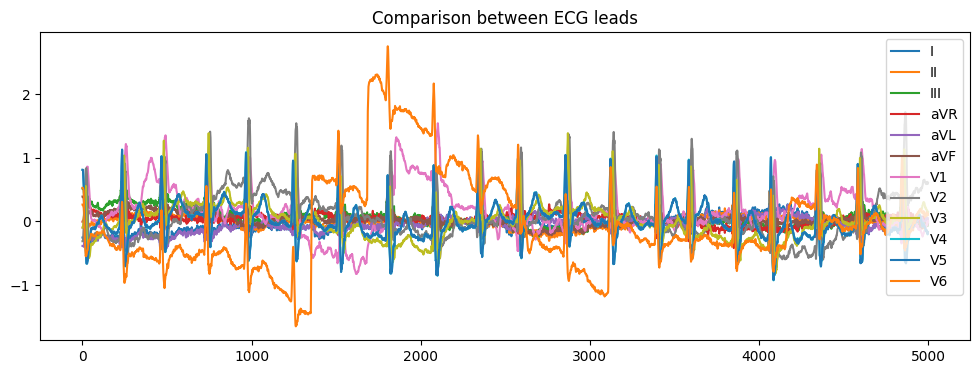

In [24]:
plt.figure(figsize=(12,4))

for i in range(12):
    plt.plot(signal[:,i], label=leads[i])

plt.legend()
plt.title("Comparison between ECG leads")
plt.show()

## Inter-record variability

Plotting the same lead across multiple recordings provides a first qualitative view of inter-subject variability. This is relevant for later privacy-oriented experiments, where subject-related signal structure is important.

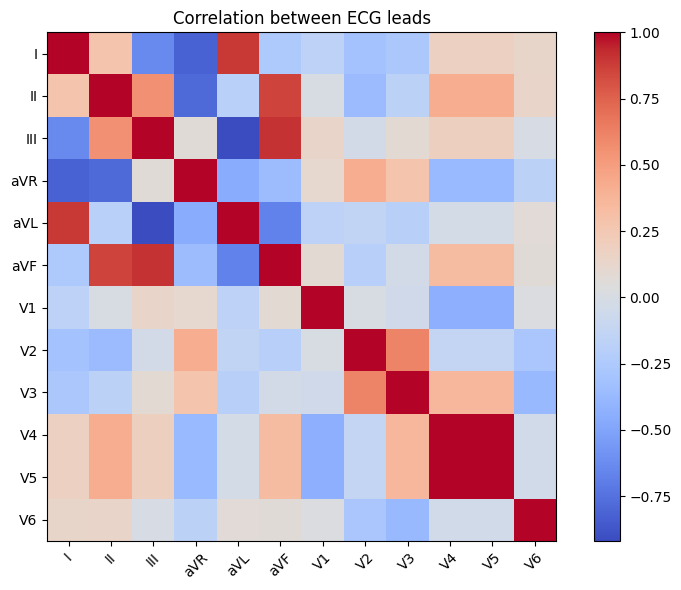

In [25]:
corr = np.corrcoef(signal.T)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation between ECG leads")
plt.xticks(range(len(leads)), leads, rotation=45)
plt.yticks(range(len(leads)), leads)
plt.tight_layout()
plt.show()

## Lead correlation analysis

This analysis evaluates the level of redundancy or complementarity across ECG leads. Strong correlations suggest overlapping information, while lower correlations indicate that some leads may provide additional signal perspectives.

This is relevant for decisions such as using a single lead or selecting a subset of leads.

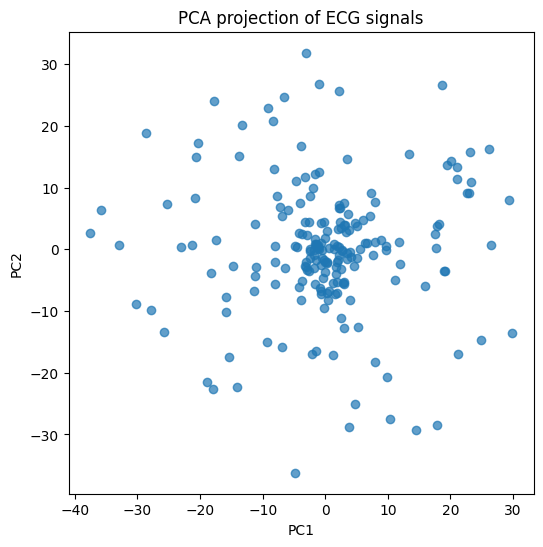

In [26]:
from sklearn.decomposition import PCA

segments = []

for hea in hea_files[:200]:
    record_path = hea.with_suffix("")
    signal, fs, leads = load_record(record_path)

    lead_signal = signal[:, 1]
    lead_signal = (lead_signal - lead_signal.mean()) / lead_signal.std()
    segments.append(lead_signal)

X = np.array(segments)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.title("PCA projection of ECG signals")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## PCA visualization

PCA is used as an exploratory tool to assess whether ECG recordings exhibit visible structure or variability in a reduced space.

In [27]:
similarity_df = compute_intra_inter_similarity(
    records=hea_files,
    loader=load_record,
    n_records=100,
    lead_idx=1,
    window_sec=2.0,
    step_sec=1.0,
    random_state=42
)

similarity_df.groupby("pair_type")["similarity"].describe()

,count,mean,std,min,25%,50%,75%,max
pair_type,,,,,,,,
inter-subject,100.0,0.009670,0.123586,-0.230293,-0.070038,-0.006553,0.060713,0.393663
intra-subject,100.0,-0.013155,0.163775,-0.488901,-0.093762,-0.031645,0.046181,0.759082


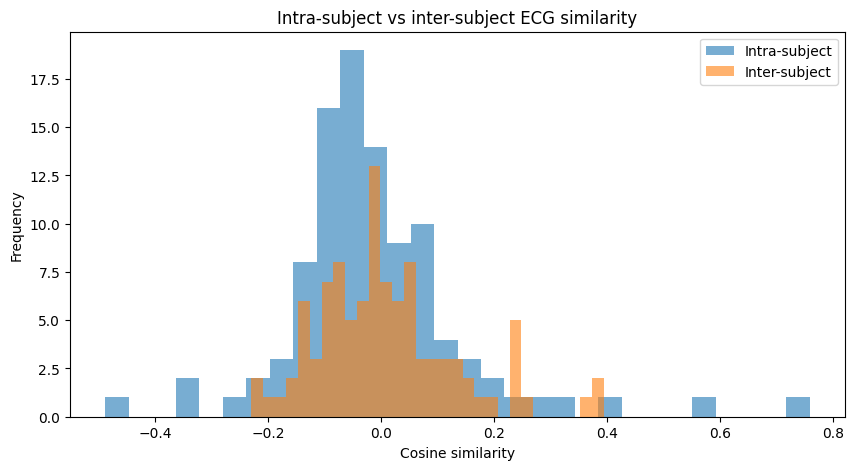

In [28]:
plot_similarity_distributions(similarity_df)

## Similarity analysis for privacy-oriented experimentation

This analysis compares ECG segments from the same record and from different records. The purpose is to assess whether the signal contains subject-related structure that may later support re-identification or linkability risk analysis.

## Implications for the experimental design

The previous analyses support several methodological decisions for the next stages of the experiment:

- whether one lead may be sufficient for a baseline setup;
- whether normalization or denoising is likely to be needed;
- whether segmentation into shorter windows is feasible;
- whether the ECG signal exhibits subject-related structure relevant for privacy-risk experiments.

Because this work is part of a thesis experiment, the EDA is used not only to describe the dataset, but also to justify the design of the next steps.

## Conclusions

This notebook provided a structured data understanding and exploratory analysis of the ECG dataset, combining:
- dataset characterization,
- demographic analysis,
- signal inspection,
- statistical analysis,
- and privacy-oriented exploratory analysis.

These results will support the design of the preprocessing, segmentation, and feature extraction stages of the thesis experiment.